In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization ko sundar banane ke liye setting
%matplotlib inline
sns.set(style="whitegrid")
print("Libraries successfully imported, Bhai!")

Libraries successfully imported, Bhai!


In [ ]:
# Path paste kijiye (Udaharan ke liye niche wala path dekhein)
path = '/content/drive/MyDrive/Project/Online_Retail_Cleaned.csv'

# Data load karna
df = pd.read_csv(path)

print("Data successfully loaded into Python!")
# Pehli 5 rows dekhne ke liye
df.head()

Data successfully loaded into Python!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
# 1. Check counts and data types
print("--- Data Info ---")
df.info()

# 2. Check for missing values (Just to be double sure)
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Statistical Summary (Mean, Min, Max etc.)
print("\n--- Statistical Summary ---")
df.describe()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397924 entries, 0 to 397923
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   InvoiceNo      397924 non-null  int64  
 1   StockCode      397924 non-null  object 
 2   Description    397924 non-null  object 
 3   Quantity       397924 non-null  int64  
 4   InvoiceDate    397924 non-null  object 
 5   UnitPrice      397924 non-null  float64
 6   CustomerID     397924 non-null  float64
 7   Country        397924 non-null  object 
 8   Total_Revenue  397924 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 27.3+ MB

--- Missing Values ---
InvoiceNo        0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID       0
Country          0
Total_Revenue    0
dtype: int64

--- Statistical Summary ---


,InvoiceNo,Quantity,UnitPrice,CustomerID,Total_Revenue
count,397924.000000,397924.000000,397924.000000,397924.000000,397924.000000
mean,560617.126645,13.021823,3.116174,15294.315171,22.394749
std,13106.167695,180.420210,22.096788,1713.169877,309.055588
min,536365.000000,1.000000,0.000000,12346.000000,0.000000
25%,549234.000000,2.000000,1.250000,13969.000000,4.680000
50%,561893.000000,6.000000,1.950000,15159.000000,11.800000
75%,572090.000000,12.000000,3.750000,16795.000000,19.800000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000


In [ ]:
# Date ko text se datetime format mein badalna
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Ab check kijiye ki type badla ya nahi
print("InvoiceDate ka naya type:", df['InvoiceDate'].dtype)

InvoiceDate ka naya type: datetime64[ns]


In [ ]:
# 1. Ghanta (Hour) nikalna (0 se 23 tak)
df['Hour'] = df['InvoiceDate'].dt.hour

# 2. Din ka naam nikalna (Monday, Tuesday...)
df['Day_Name'] = df['InvoiceDate'].dt.day_name()

# 3. Mahine ka naam nikalna
df['Month_Name'] = df['InvoiceDate'].dt.month_name()

# Check karne ke liye ki naye columns aaye ya nahi
df[['InvoiceDate', 'Hour', 'Day_Name', 'Month_Name']].head()

,InvoiceDate,Hour,Day_Name,Month_Name
0,2010-12-01 08:26:00,8,Wednesday,December
1,2010-12-01 08:26:00,8,Wednesday,December
2,2010-12-01 08:26:00,8,Wednesday,December
3,2010-12-01 08:26:00,8,Wednesday,December
4,2010-12-01 08:26:00,8,Wednesday,December


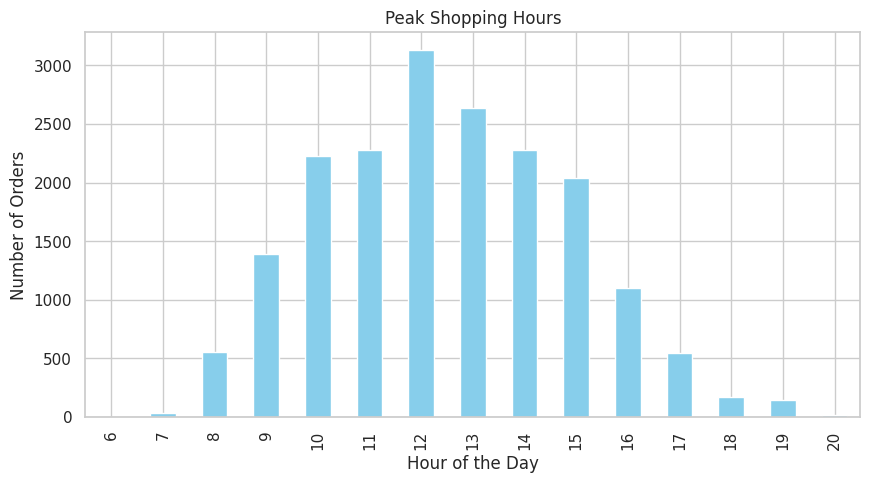

In [ ]:
# Ghante ke hisaab se orders count karna
hourly_sales = df.groupby('Hour')['InvoiceNo'].nunique()

# Chota sa graph banana
hourly_sales.plot(kind='bar', color='skyblue', figsize=(10,5))
plt.title('Peak Shopping Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.show()

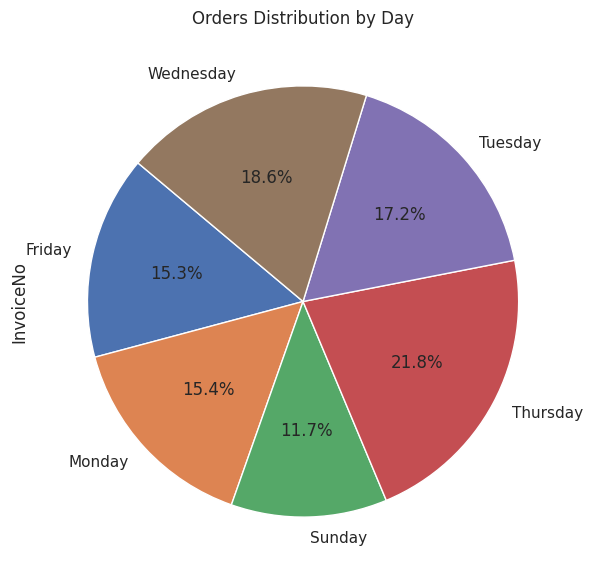

In [ ]:
# Din ke hisaab se orders count karna
day_sales = df.groupby('Day_Name')['InvoiceNo'].nunique()

# Graph banana
day_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7), startangle=140)
plt.title('Orders Distribution by Day')
plt.show()

In [ ]:
# Quantity ke hisaab se top 5 products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)

print("Top 5 Products by Quantity Sold:")
print(top_products)

Top 5 Products by Quantity Sold:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
Name: Quantity, dtype: int64


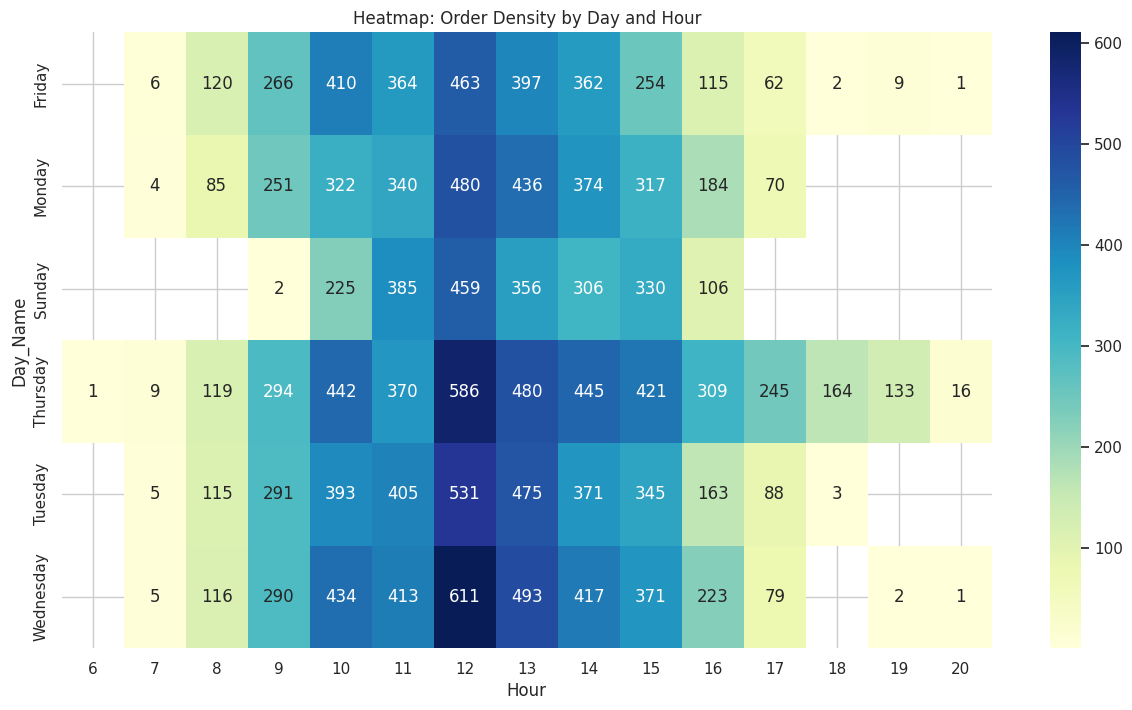

In [ ]:
# 1. Pivot Table banana (Day vs Hour)
heatmap_data = df.pivot_table(index='Day_Name', columns='Hour', values='InvoiceNo', aggfunc='nunique')

# 2. Heatmap Draw karna
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Heatmap: Order Density by Day and Hour')
plt.show()

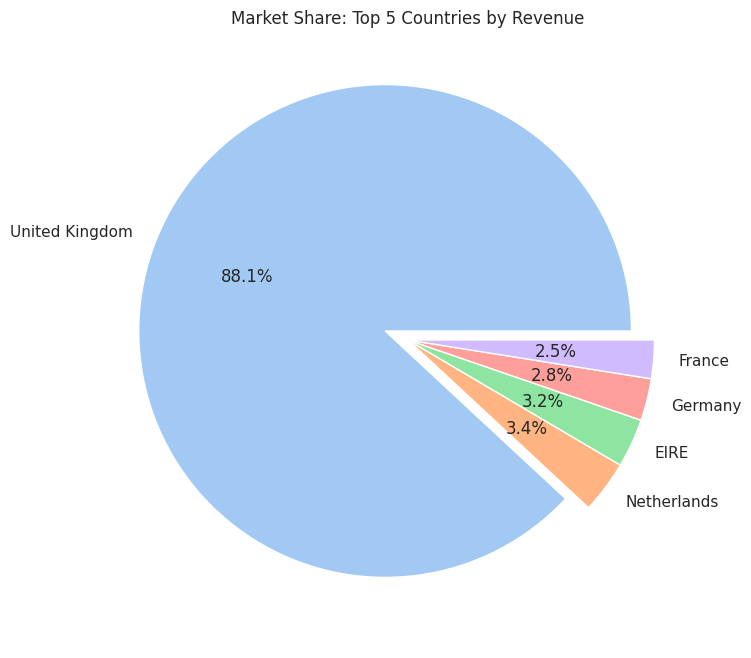

In [ ]:
# 1. Top 5 countries ka revenue nikalna
country_revenue = df.groupby('Country')['Total_Revenue'].sum().sort_values(ascending=False).head(5)

# 2. Pie Chart banana
plt.figure(figsize=(8, 8))
country_revenue.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), explode=(0.1, 0, 0, 0, 0))
plt.title('Market Share: Top 5 Countries by Revenue')
plt.ylabel('') # Y-axis label hatane ke liye
plt.show()

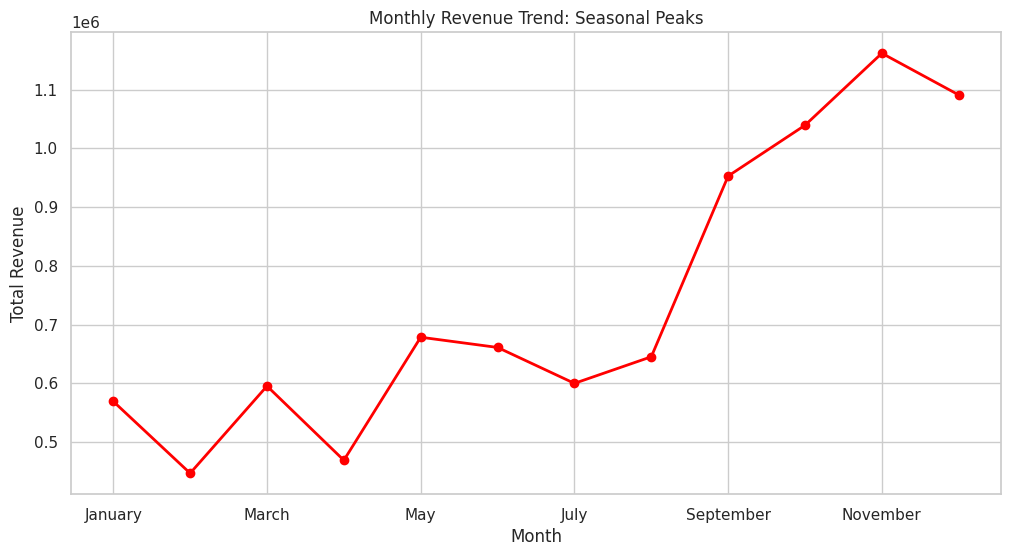

In [ ]:
# 1. Mahine ke hisaab se revenue
monthly_trend = df.groupby('Month_Name')['Total_Revenue'].sum()

# 2. Mahino ko sahi order mein lagana (Jan to Dec)
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_trend = monthly_trend.reindex(months_order)

# 3. Line Chart banana
plt.figure(figsize=(12, 6))
monthly_trend.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Monthly Revenue Trend: Seasonal Peaks')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()